## Working with Application Programming Interfaces (APIs)

Application Programming Interfaces (APIs) are a set of rules and protocols that allow different software applications to communicate with each other. They enable developers to access data and functionality from external services, libraries, or platforms without needing to understand the underlying code or infrastructure. Rather than downloading data files manually, APIs allow us to programmatically request and retrieve data directly from a web service.

In this section, we will have a brief look at how to use some common APIs for economic data retrieval using Python. We will cover the following:

- [Banco de España's Statistics Web Service](https://www.bde.es/webbe/en/estadisticas/recursos/api-estadisticas-bde.html)
- [ECB Data Portal](https://data.ecb.europa.eu/help/api/overview)
- [Fred API](https://fred.stlouisfed.org/docs/api/fred/) by the Federal Reserve Bank of St. Louis

These APIs provide access to a wide range of economic and financial data, including interest rates, exchange rates, inflation rates, GDP figures, and more. By using these APIs, we can automate the process of data retrieval, ensuring that we always have access to the most up-to-date information for our analyses. I highly recommend that you make use of APIs whenever possible to streamline your data collection process.

### Banco de España's Statistics Web Service

[Banco de España's Statistics Web Service](https://www.bde.es/webbe/en/estadisticas/recursos/api-estadisticas-bde.html) provides a way to programmatically retrieve data from the Banco de España's databases including data from [BIEST](https://app.bde.es/bie_www/bie_wwwias/xml/Arranque.html). Since Banco de España does not provide an official Python package to access their API, we can use the `requests` library to make HTTP requests and retrieve data in JSON (JavaScript Object Notation) format. We can then parse the JSON data and convert it into a Pandas DataFrame for further analysis. 

To this end, we first import the necessary libraries

In [1]:
import requests
import pandas as pd

Next, we define a class to interact with the Banco de España API^[Note that creating the class is not strictly necessary, but it helps to organize the code.]

In [2]:
class BancoDeEspanaAPI:
    def __init__(self, language='en'):
      self.language = language

    def request(self, url):
      response = requests.get(url)
      return response.json()

    def get_series(self, series, time_range='MAX'):

      # Prepare the series parameter
      if isinstance(series, list):
          series_list = ','.join(series)
      else:
          series_list = series

      # Download the data for the specified series
      url = f"https://app.bde.es/bierest/resources/srdatosapp/listaSeries?idioma={self.language}&series={series_list}&rango={time_range}"
      json_response = self.request(url)

      # Initialize an empty dataframe to store the results
      df = pd.DataFrame()

      # Go over each series in the response and extract the data
      for series_data in json_response:

        # Extract series name, dates, and values
        series_name = series_data['serie']
        dates = series_data['fechas']
        values = series_data['valores']

        # Add the data to the dataframe
        df[series_name] = pd.Series(data=values, index=pd.to_datetime(dates).date)

      # Sort the dataframe by index (date)
      df = df.sort_index()

      return df

We can then create an instance of the `BancoDeEspanaAPI` class and use its methods to retrieve data. For example, to get the latest data for a specific series, we can use the `get_series()` method

In [3]:
bde = BancoDeEspanaAPI()
df = bde.get_series(['DTNPDE2010_P0000P_PS_APU', 'DTNSEC2010_S0000P_APU_SUMAMOVIL'])

Now, the requested series are in the DataFrame `df` and we can manipulate or analyze them as needed. For example, we can display the retrieved data

In [4]:
df.tail()

,DTNPDE2010_P0000P_PS_APU,DTNSEC2010_S0000P_APU_SUMAMOVIL
2024-07-01,104.2,-2.8
2024-10-01,101.6,-3.2
2025-01-01,103.4,-3.2
2025-04-01,103.5,-3.2
2025-07-01,103.2,-2.9


or plot it

<Axes: >

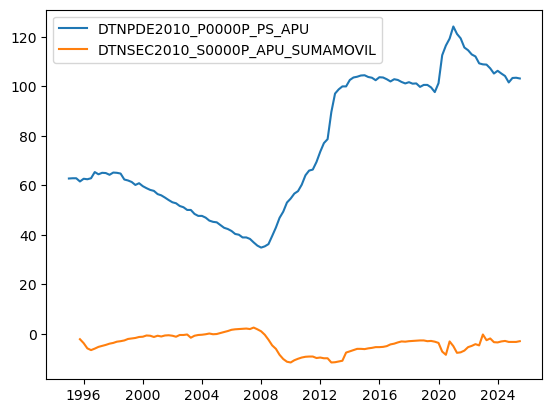

In [5]:
df.plot()

This is a very basic implementation of how to interact with the Banco de España API using Python. You can extend this class to include more functionality, such as handling different data formats, error handling, and more advanced data processing as needed. To get the series keys for the data you want to retrieve, you can use the [BIEST](https://app.bde.es/bie_www/bie_wwwias/xml/Arranque.html) tool provided by Banco de España.


### ECB Data Portal & Other SDMX APIs

The [ECB Data Portal](https://data.ecb.europa.eu/help/api/overview) provides access to a wide range of economic and financial data from the European Central Bank. Similar to Banco de España, the ECB does not provide an official Python package for their API. However, the ECB follows the [SDMX](https://sdmx.org/) standard for data exchange, which allows us to retrieve data in a structured format. We can use the `sdmx` library in Python to interact with the ECB API and retrieve data.

First, we import the necessary libraries

In [6]:
import sdmx
import pandas as pd

Then, we initialize a connection to the ECB API

In [7]:
ecb = sdmx.Client("ECB")

Suppose we want to retrieve the HICP inflation rate for Spain from January 2019 to June 2019. This series has the following key: `ICP.M.ES.N.000000.4.ANR`.

To download it we need to specify the appropriate parameters and make a request to the ECB API

In [8]:
key = 'M.ES.N.000000.4.ANR' # Need key without the 'ICP.' prefix
params = dict(startPeriod="2019-01", endPeriod="2019-06") # This is optional
data = ecb.data("ICP", key=key, params=params).data[0] # ICP prefix needs to be specified here
df = sdmx.to_pandas(data).to_frame()

Now, the requested data is in the DataFrame `df` and we can manipulate or analyze it as needed. For example, we can display the retrieved data

In [9]:
df.tail()

value
FREQ REF_AREA ADJUSTMENT ICP_ITEM STS_INSTITUTION ICP_SUFFIX TIME_PERIOD       
M    ES       N          000000   4               ANR        2019-02        1.1
                                                             2019-03        1.3
                                                             2019-04        1.6
                                                             2019-05        0.9
                                                             2019-06        0.6

Note that this is a multi-index DataFrame. We can reset the index to make it easier to work with

In [10]:
df = df.reset_index()
df = df.set_index('TIME_PERIOD')
df = df.loc[:, ['value']]
df = df.rename(columns={'value': 'inflation_rate'})

We can plot the data as usual

<Axes: xlabel='TIME_PERIOD'>

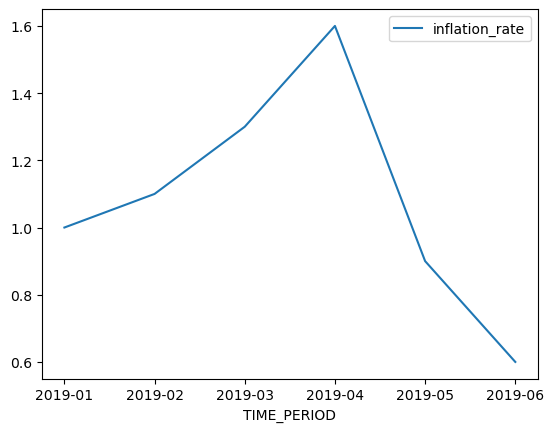

In [11]:
df.plot()

These are just basic examples of how to interact with the ECB API using Python. The `sdmx` library supports many more features. 


:::{.callout-tip}

### Other SDMX Data Providers

The SDMX standard is used by various international organizations for data exchange. Some other notable SDMX APIs include:

- Eurostat
- Bank for International Settlements (BIS)
- International Monetary Fund (IMF)
- OECD

You can find a list of SDMX data providers implemented in the `sdmx` package [here](https://sdmx1.readthedocs.io/en/latest/). To use them in the code above you simply need to replace `'ECB'` with the appropriate provider name.
:::


### Fred API

The [Fred API](https://fred.stlouisfed.org/docs/api/fred/) by the Federal Reserve Bank of St. Louis provides access to a vast amount of economic data, including interest rates, inflation rates, GDP figures, and more. To use the Fred API, we need to sign up for an API key on the Fred website. Once we have the API key, we can use the `pyfredapi` library in Python to interact with the Fred API and retrieve data.

The Fred API works a little differently from the previous two APIs we have seen since it requires an API key for authentication. You can sign up for a free API key on the [Fred website](https://fred.stlouisfed.org/docs/api/api_key.html). Note that these keys are personal and should not be shared publicly. For this reason, the key is not included directly in the code examples below. Instead, you should follow the [instructions](https://pyfredapi.readthedocs.io/en/latest/) in the `pyfredapi` documentation to set up your API key securely. 

Once we have set the API key, we import the necessary libraries

In [12]:
import pyfredapi as pf

Then, we can download the series for GDP (series ID: `GDP`) as follows

In [13]:
df = pf.get_series('GDP') # Note that you can provide the API key manually by adding the parameter api_key='YOUR_API_KEY' if you have not set it up as an environment variable

We can then display the retrieved data

In [14]:
df.tail()

,realtime_start,realtime_end,date,value
314,2025-12-23,2025-12-23,2024-07-01,29511.664
315,2025-12-23,2025-12-23,2024-10-01,29825.182
316,2025-12-23,2025-12-23,2025-01-01,30042.113
317,2025-12-23,2025-12-23,2025-04-01,30485.729
318,2025-12-23,2025-12-23,2025-07-01,31095.089


Cleaning up the DataFrame a bit

In [15]:
df = df.rename(columns={'value': 'gdp'}) # Rename the 'value' column to 'gdp'
df['date'] = pd.to_datetime(df['date']) # Convert the 'date' column to datetime format
df = df.set_index('date') # Set the 'date' column as the index
df = df.loc[:, ['gdp']] # Keep only the 'gdp' column

Now it looks better

In [16]:
df.tail()

,gdp
date,
2024-07-01,29511.664
2024-10-01,29825.182
2025-01-01,30042.113
2025-04-01,30485.729
2025-07-01,31095.089


and to plot it, we can simply do

<Axes: xlabel='date'>

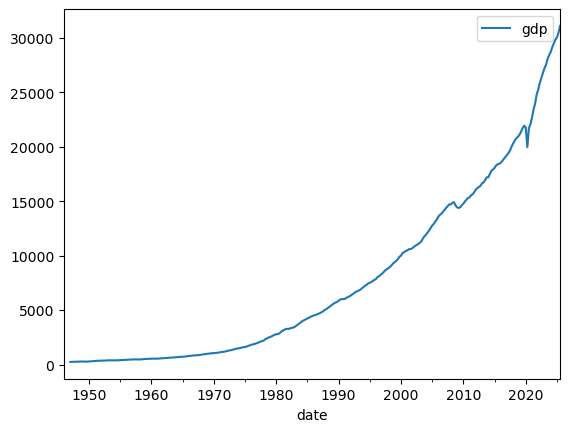

In [17]:
df.plot()

To see all the functionality provided by the `pyfredapi` library, please refer to the [official documentation](https://pyfredapi.readthedocs.io/en/latest/).
